In [6]:
import pandas as pd
import numpy as np
import os
from scipy import stats

# Configuration
RAW_DIR = r'C:\Users\vinay\OneDrive\Desktop\project\data\raw'
NAV_FILE = os.path.join(RAW_DIR, '02_nav_history.csv')
BENCH_FILE = os.path.join(RAW_DIR, '10_benchmark_indices.csv')

# Load Data
df_nav = pd.read_csv(NAV_FILE)
df_bench = pd.read_csv(BENCH_FILE)

# Column Detection
bench_col = [c for c in df_bench.columns if c.lower() != 'date'][0]

# Prepare Data
df_nav['date'] = pd.to_datetime(df_nav['date'])
df_bench['date'] = pd.to_datetime(df_bench['date'])
df_nav['nav'] = pd.to_numeric(df_nav['nav'], errors='coerce')
df_bench[bench_col] = pd.to_numeric(df_bench[bench_col], errors='coerce')

df_nav = df_nav.sort_values(by=['amfi_code', 'date'])
print("✅ Data loaded successfully. Benchmark column detected:", bench_col)

✅ Data loaded successfully. Benchmark column detected: index_name


In [7]:
# Task 1: Compute Daily Returns
df_nav['daily_return'] = df_nav.groupby('amfi_code')['nav'].pct_change()
df_nav = df_nav.dropna(subset=['daily_return'])
print("✅ Daily returns computed.")
df_nav.head()

✅ Daily returns computed.


,amfi_code,date,nav,daily_return
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639


In [8]:
# Task 2: Compute CAGR
def get_cagr(df, years):
    end_date = df['date'].max()
    start_date = end_date - pd.DateOffset(years=years)
    df_f = df[(df['date'] >= start_date) & (df['date'] <= end_date)]
    data = df_f.groupby('amfi_code').agg(start=('nav', 'first'), end=('nav', 'last'))
    return (data['end'] / data['start']) ** (1 / years) - 1

cagr_data = pd.concat([get_cagr(df_nav, 1), get_cagr(df_nav, 3), get_cagr(df_nav, 5)], axis=1)
cagr_data.columns = ['CAGR_1Y', 'CAGR_3Y', 'CAGR_5Y']
print("✅ CAGR computed.")
cagr_data.head()

✅ CAGR computed.


,CAGR_1Y,CAGR_3Y,CAGR_5Y
amfi_code,,,
100016,-0.022243,0.012926,0.025290
100025,0.037050,0.039164,0.039866
100033,0.532324,0.324425,0.264128
101206,0.479241,0.289677,0.204150
101207,-0.239860,-0.041524,0.071873


In [9]:
# Tasks 3 & 4: Sharpe and Sortino
risk = df_nav.groupby('amfi_code').agg(mean=('daily_return', 'mean'), std=('daily_return', 'std'))
risk['sharpe'] = (risk['mean'] - 0.065/252) / risk['std'] * np.sqrt(252)

downside = df_nav[df_nav['daily_return'] < 0].groupby('amfi_code')['daily_return'].std()
risk['sortino'] = (risk['mean'] - 0.065/252) / downside * np.sqrt(252)
print("✅ Sharpe and Sortino ratios computed.")
risk[['sharpe', 'sortino']].head()

✅ Sharpe and Sortino ratios computed.


,sharpe,sortino
amfi_code,,
100016,-0.201517,-0.351047
100025,-0.567095,-0.941821
100033,1.093699,1.829134
101206,1.027213,1.799563
101207,0.162661,0.276644


In [10]:
# Task 5: Alpha and Beta (OLS Regression)
merged = pd.merge(df_nav, df_bench[['date', bench_col]], on='date', how='inner')

def get_alpha_beta(group):
    g = group.dropna(subset=[bench_col, 'daily_return'])
    if len(g) < 2: return pd.Series({'beta': 0, 'alpha': 0})
    slope, intercept, _, _, _ = stats.linregress(g[bench_col], g['daily_return'])
    return pd.Series({'beta': slope, 'alpha': intercept * 252})

ab_metrics = merged.groupby('amfi_code', group_keys=False).apply(get_alpha_beta, include_groups=False)
print("✅ Alpha and Beta computed.")
ab_metrics.head()

✅ Alpha and Beta computed.


,beta,alpha
amfi_code,,
100016,0,0
100025,0,0
100033,0,0
101206,0,0
101207,0,0


In [11]:
# Task 6: Max Drawdown
def get_mdd(x):
    return (x / x.cummax() - 1).min()

mdd = df_nav.groupby('amfi_code')['nav'].apply(get_mdd).rename('max_drawdown')

# Task 7: Fund Scorecard
df_scorecard = pd.concat([cagr_data, risk[['sharpe']], ab_metrics[['alpha']], mdd], axis=1).fillna(0)
df_scorecard['score'] = (
    df_scorecard['CAGR_3Y'].rank(pct=True) * 0.30 +
    df_scorecard['sharpe'].rank(pct=True) * 0.25 +
    df_scorecard['alpha'].rank(pct=True) * 0.20 +
    (1 - df_scorecard['max_drawdown'].rank(pct=True)) * 0.10
)

# Export deliverables
df_scorecard.to_csv('fund_scorecard.csv')
ab_metrics.to_csv('alpha_beta.csv')
print("✅ Deliverables exported: fund_scorecard.csv, alpha_beta.csv")
df_scorecard.head()

✅ Deliverables exported: fund_scorecard.csv, alpha_beta.csv


,CAGR_1Y,CAGR_3Y,CAGR_5Y,sharpe,alpha,max_drawdown,score
amfi_code,,,,,,,
100016,-0.022243,0.012926,0.025290,-0.201517,0,-0.247344,0.26750
100025,0.037050,0.039164,0.039866,-0.567095,0,-0.043083,0.17500
100033,0.532324,0.324425,0.264128,1.093699,0,-0.162172,0.64000
101206,0.479241,0.289677,0.204150,1.027213,0,-0.112916,0.56250
101207,-0.239860,-0.041524,0.071873,0.162661,0,-0.354469,0.29125


✅ Benchmark comparison chart saved as 'benchmark_comparison.png'


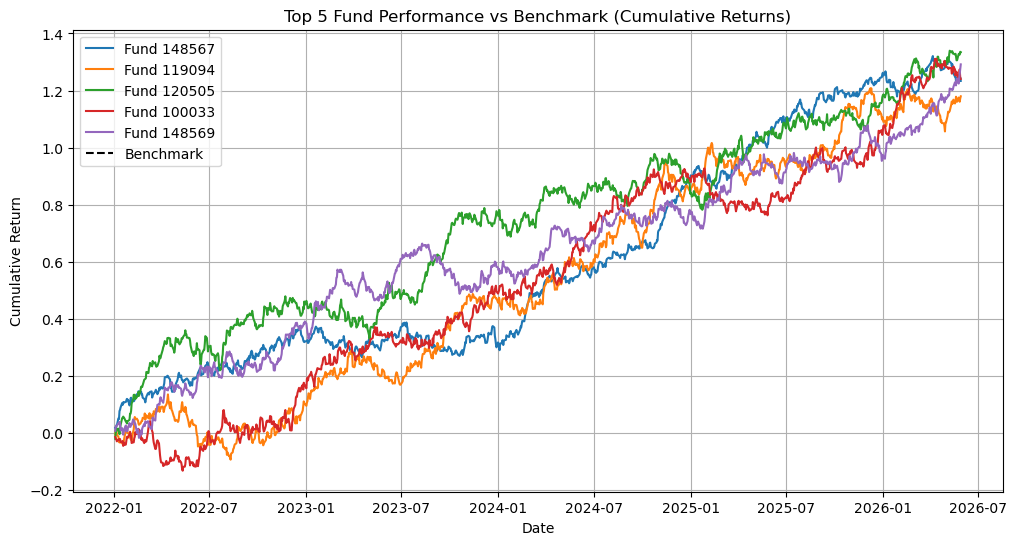

In [12]:
import matplotlib.pyplot as plt

# 1. Identify Top 5 Funds based on your scorecard
top_5 = df_scorecard.nlargest(5, 'score').index

# 2. Setup Plot
plt.figure(figsize=(12, 6))

# Plot Top 5 Funds
for amfi in top_5:
    fund_data = df_nav[df_nav['amfi_code'] == amfi].set_index('date')['daily_return'].cumsum()
    plt.plot(fund_data, label=f'Fund {amfi}')

# Plot Benchmark (Assuming it's in df_bench)
plt.plot(df_bench.set_index('date')[bench_col].cumsum(), label='Benchmark', color='black', linestyle='--')

plt.title('Top 5 Fund Performance vs Benchmark (Cumulative Returns)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)

# 3. Save as PNG
plt.savefig('benchmark_comparison.png')
print("✅ Benchmark comparison chart saved as 'benchmark_comparison.png'")
plt.show()